In [36]:
%matplotlib widget

In [37]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [38]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)

In [39]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > err_flux[8] and HB > err_flux[1] else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > err_flux[12] and HA > err_flux[2] else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > err_flux[3] and HA > err_flux[2] else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

0.5177984621055078 nan nan
0.07559964132898774 nan nan
0.15713182703323145 -0.5872109581550179 nan
0.07304989869327094 -0.53685354989834 nan
0.08363341225576414 -0.593721193552781 nan
0.07743008309960143 -0.6421551130919868 nan
0.1307914389451852 -0.6830720472502575 -1.4632835232299686
0.015300749278104583 -0.6243930175512312 nan
-0.13180131242433216 -0.5242882437960696 nan
-0.17271895653725253 -0.4641232985676516 nan
-0.1835629326813202 -0.371674680251679 nan
-0.19565270777355193 -0.4031980710570058 nan
-0.17817645064187726 -0.3661743527848244 nan
nan -0.3404888683390666 nan
nan -0.32811705868787033 nan
-0.23117733034191074 -0.424748375682985 nan
nan -0.39446501390463373 nan
-0.20723591794624505 -0.2216582405149306 nan
0.014414800644730448 -0.35604240399033404 nan
nan -0.20236664291160456 nan


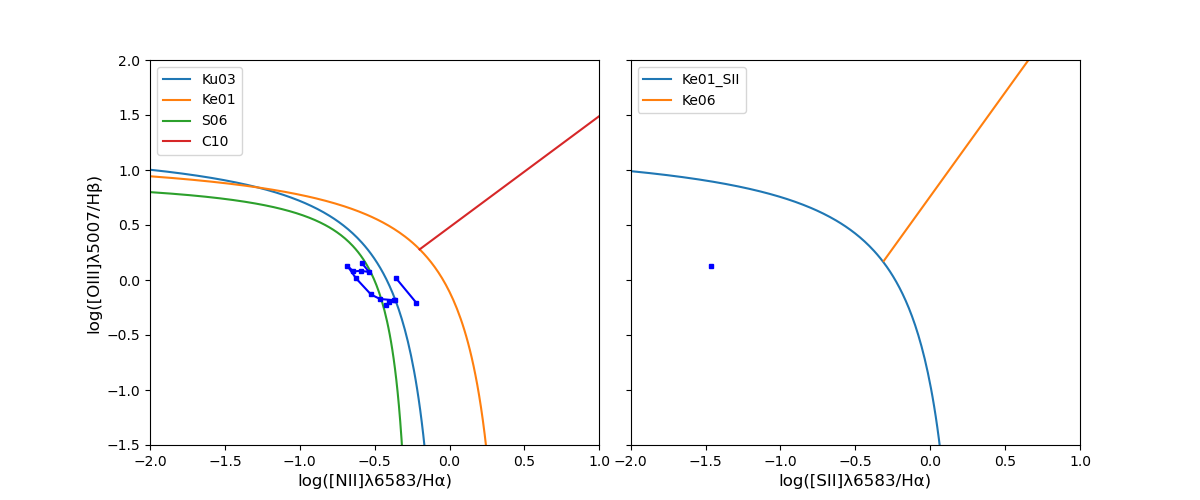

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03')
ax[0].plot(x1, Ke01(x1), label = 'Ke01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
OIII_HB_ok2 =[]
for i in range(20):
    spectrum = spectra[i]
    oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
    print(oiii_hb, nii_ha, sii_ha)
    NII_HA.append(nii_ha)
    OIII_HB.append(oiii_hb)
    if np.isnan(oiii_hb) == False and np.isnan(sii_ha) == False:    
        SII_HA.append(sii_ha)
        OIII_HB_ok2.append(oiii_hb)
    
ax[0].plot(NII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)   
#ax[0].plot(NII_HA[0], OIII_HB[0], color='red', marker= 's', linestyle='-', markersize = 3)               
ax[1].plot(SII_HA, OIII_HB_ok2, color='blue', marker= 's', linestyle='-', markersize = 3)
#ax[1].plot(SII_HA[0], OIII_HB_ok2[0], color='green', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')

In [41]:
NII_HA

[nan,
 nan,
 -0.5872109581550179,
 -0.53685354989834,
 -0.593721193552781,
 -0.6421551130919868,
 -0.6830720472502575,
 -0.6243930175512312,
 -0.5242882437960696,
 -0.4641232985676516,
 -0.371674680251679,
 -0.4031980710570058,
 -0.3661743527848244,
 -0.3404888683390666,
 -0.32811705868787033,
 -0.424748375682985,
 -0.39446501390463373,
 -0.2216582405149306,
 -0.35604240399033404,
 -0.20236664291160456]

In [42]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

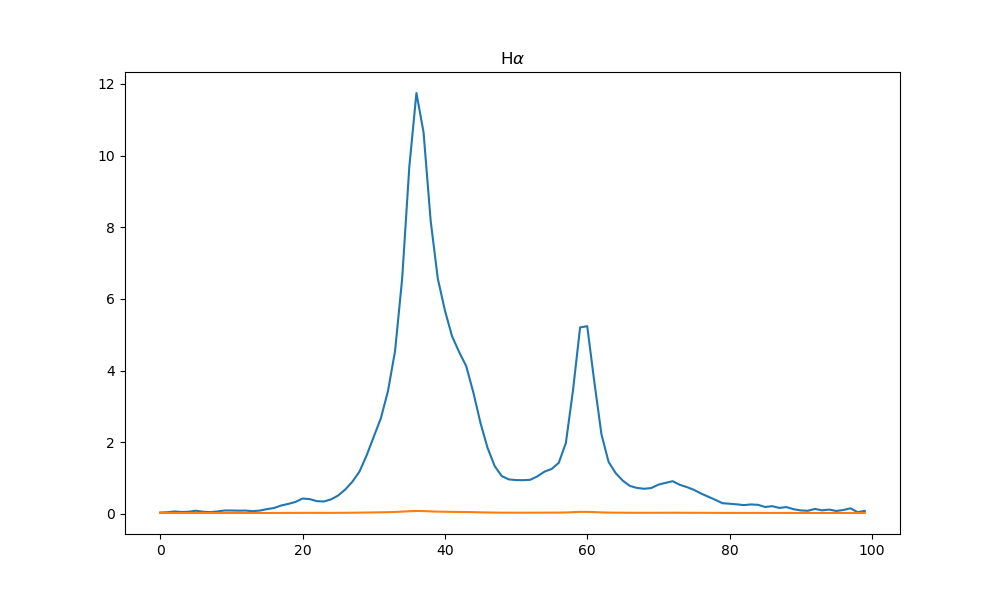

In [43]:
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')